In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [7]:
df = pd.read_csv('https://raw.githubusercontent.com/campusx-official/100-days-of-machine-learning/main/day37-handling-missing-categorical-data/train.csv', usecols=['GarageQual', 'FireplaceQu', 'SalePrice'])

In [10]:
df.head(5)

,FireplaceQu,GarageQual,SalePrice
0,NaN,TA,208500
1,TA,TA,181500
2,TA,TA,223500
3,Gd,TA,140000
4,TA,TA,250000


In [12]:
df.isnull().mean() * 100

FireplaceQu    47.260274
GarageQual      5.547945
SalePrice       0.000000
dtype: float64

Text(0.5, 0, 'GarageQual')

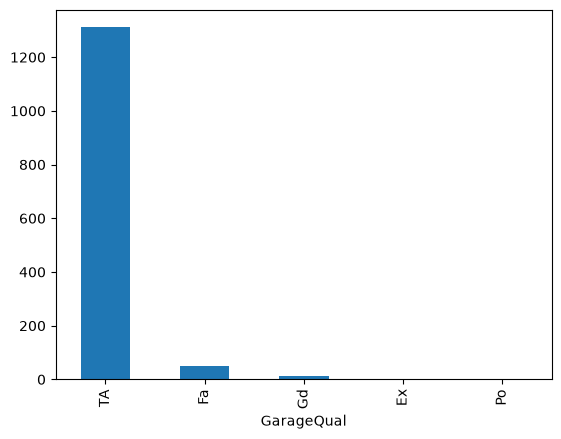

In [15]:
df['GarageQual'].value_counts().sort_values(ascending=False).plot.bar()
plt.xlabel('GarageQual')

In [16]:
df['GarageQual'].mode()[0]

'TA'

ValueError: zero-size array to reduction operation fmax which has no identity

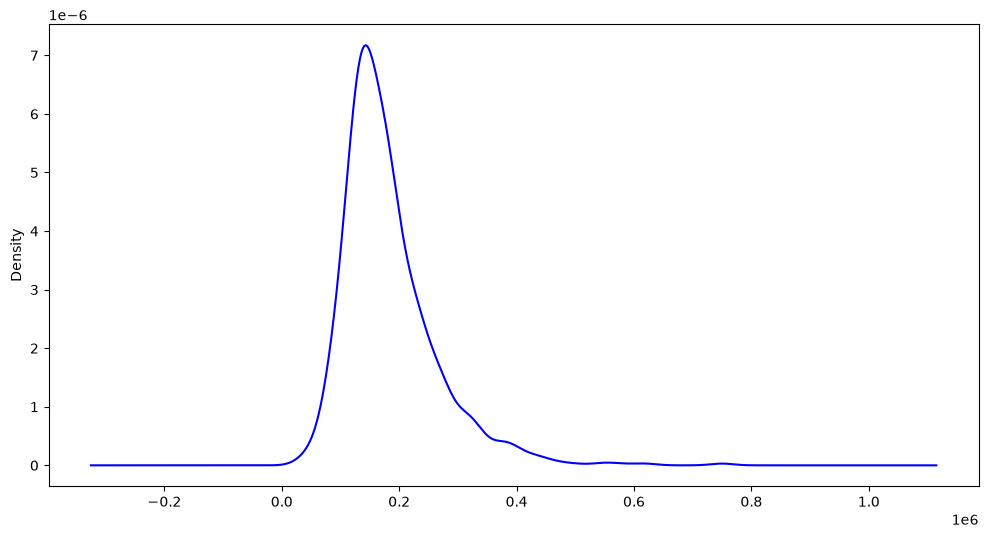

In [26]:
fig = plt.figure(figsize=(12, 6))
ax = fig.add_subplot(111)

df[df['GarageQual'] == "TA"]['SalePrice'].plot(kind='kde', ax=ax, color='blue')

df[df['GarageQual'].isnull()]['SalePrice'].plot(kind='kde', ax=ax, color='red')

lines, labels = ax.get_legend_handles_labels()
labels = ["Housing with TA", " Housing eith NA "]
ax.legend(lines, labels, loc="best")
plt.title("GarageQual")

In [19]:
temp = df[df['GarageQual'] == "TA"]['SalePrice']

In [21]:
df['GarageQual'].fillna("TA", inplace=True)

<Axes: xlabel='GarageQual'>

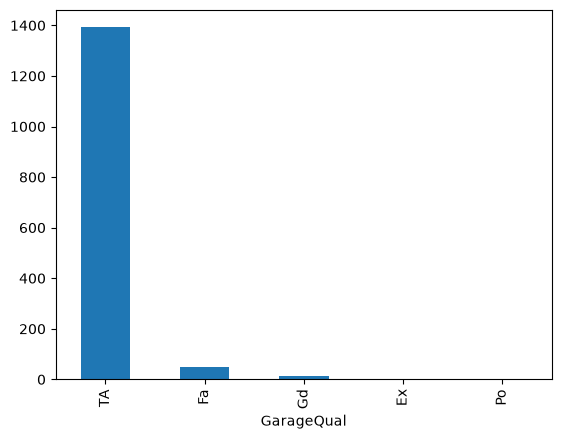

In [22]:
df['GarageQual'].value_counts().plot(kind='bar')

Text(0.5, 1.0, 'GrageQual')

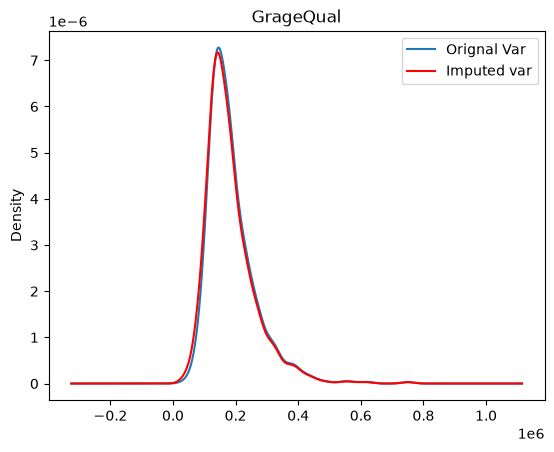

In [24]:
fig = plt.figure()
ax = fig.add_subplot(111)
temp.plot(kind='kde', ax=ax)

# Distribution of the variabl after imputation
df[df['GarageQual'] =="TA"]["SalePrice"].plot(kind='kde', ax=ax, color="red")

lines, labels = ax.get_legend_handles_labels()
labels = ['Orignal Var', "Imputed var"]
ax.legend(lines, labels, loc='best')

plt.title("GrageQual")

<Axes: xlabel='FireplaceQu'>

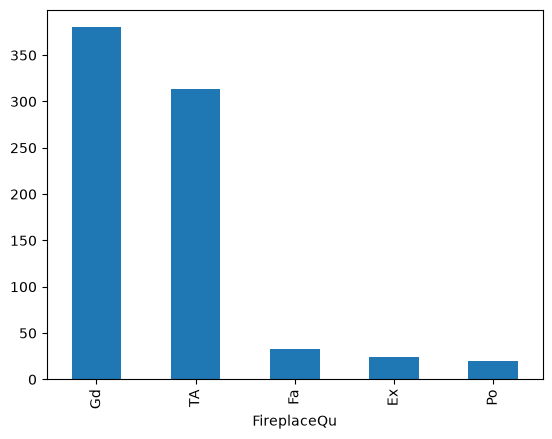

In [28]:
df['FireplaceQu'].value_counts().plot(kind='bar')

In [29]:
df['FireplaceQu'].mode()

0    Gd
Name: FireplaceQu, dtype: object

Text(0.5, 1.0, 'FireQu')

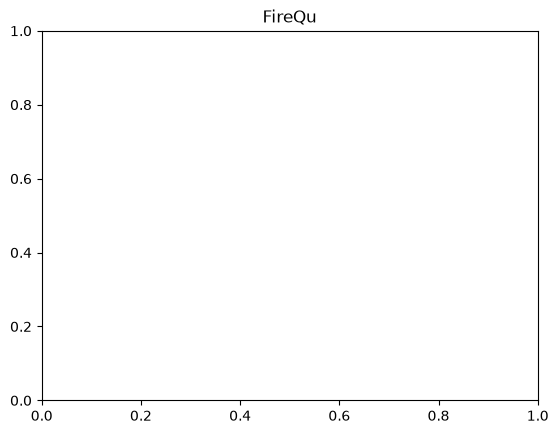

In [30]:
fig = plt.Figure()
ax= fig.add_subplot(111)

df[df['FireplaceQu']=="Gd"]["SalePrice"].plot(kind="kde", ax=ax)

df[df['FireplaceQu'].isnull()]["SalePrice"].plot(kind="kde", ax=ax, color='red')

lines, labels = ax.get_legend_handles_labels()
labels = ["Housing with Gd", "Housing with NA"]
ax.legend(lines, labels, loc="best")

plt.title("FireQu")

In [31]:
temp = df[df['FireplaceQu']=="Gd"]["SalePrice"]

In [32]:
df["FireplaceQu"].fillna('Gd', inplace=True)

<Axes: xlabel='FireplaceQu'>

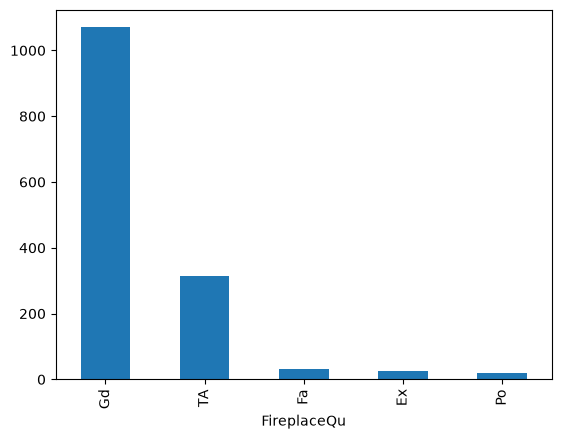

In [33]:
df['FireplaceQu'].value_counts().plot(kind='bar')

C:\Users\FDRA\AppData\Local\Temp\ipykernel_11260\2034511947.py:10: UserWarning: Mismatched number of handles and labels: len(handles) = 1 len(labels) = 2
  ax.legend(lines, labels, loc="best")


Text(0.5, 1.0, 'FireQu')

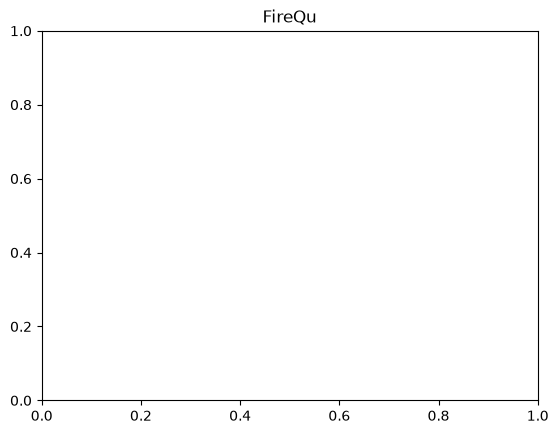

In [36]:
fig = plt.Figure()
ax= fig.add_subplot(111)

df[df['FireplaceQu']=="Gd"]["SalePrice"].plot(kind="kde", ax=ax, color='red')

# df[df['FireplaceQu'].isnull()]["SalePrice"].plot(kind="kde", ax=ax, color='red')

lines, labels = ax.get_legend_handles_labels()
labels = ["orignal Gd", "After Gd Imputed"]
ax.legend(lines, labels, loc="best")

plt.title("FireQu")

In [37]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(df.drop(columns=['SalePrice']), df["SalePrice"], test_size=0.2, random_state=42)

In [38]:
from sklearn.impute import SimpleImputer
si = SimpleImputer(strategy='most_frequent')


In [39]:
X_train = si.fit_transform(X_train)
X_test = si.transform(X_test)

In [40]:
si.statistics_

array(['Gd', 'TA'], dtype=object)